In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def extract_mat_file(filepath):
    """
    Extract BFData and ReconParams from a MATLAB v7.3 .mat file
    """
    # Load the file
    f = h5py.File(filepath, 'r')
    
    # Extract BFData
    BFData_dict = {}
    bfdata_group = f['BFData']
    
    # Get the complex arrays (IQ_xAM and IQ_xBmode)
    for array_name in ['IQ_xAM', 'IQ_xBMode']:
        if array_name in bfdata_group:
            # Load the raw data
            raw_data = bfdata_group[array_name][:]
            
            # Check the dtype and convert appropriately
            if 'complex' in str(raw_data.dtype):
                # Already complex type
                BFData_dict[array_name] = raw_data
            elif raw_data.dtype == np.float64 or raw_data.dtype == np.float32:
                # Real data only
                BFData_dict[array_name] = raw_data
            else:
                # Try to interpret as complex (MATLAB v7.3 stores complex as real+imag in structured dtype)
                try:
                    # Check if it's a structured array with real and imag fields
                    if raw_data.dtype.names is not None:
                        if 'real' in raw_data.dtype.names and 'imag' in raw_data.dtype.names:
                            complex_data = raw_data['real'] + 1j * raw_data['imag']
                            BFData_dict[array_name] = complex_data
                        else:
                            # Try to access fields dynamically
                            fields = list(raw_data.dtype.names)
                            if len(fields) >= 2:
                                complex_data = raw_data[fields[0]] + 1j * raw_data[fields[1]]
                                BFData_dict[array_name] = complex_data
                            else:
                                BFData_dict[array_name] = raw_data
                    else:
                        BFData_dict[array_name] = raw_data
                except:
                    BFData_dict[array_name] = raw_data
            
            print(f"Loaded {array_name} with shape: {BFData_dict[array_name].shape}, dtype: {BFData_dict[array_name].dtype}")
        elif array_name.lower() in [k.lower() for k in bfdata_group.keys()]:
            # Case-insensitive fallback
            actual_name = next(k for k in bfdata_group.keys() if k.lower() == array_name.lower())
            raw_data = bfdata_group[actual_name][:]
            
            # Same conversion logic
            if 'complex' in str(raw_data.dtype):
                BFData_dict[actual_name] = raw_data
            elif raw_data.dtype == np.float64 or raw_data.dtype == np.float32:
                BFData_dict[actual_name] = raw_data
            else:
                try:
                    if raw_data.dtype.names is not None:
                        if 'real' in raw_data.dtype.names and 'imag' in raw_data.dtype.names:
                            complex_data = raw_data['real'] + 1j * raw_data['imag']
                            BFData_dict[actual_name] = complex_data
                        else:
                            fields = list(raw_data.dtype.names)
                            if len(fields) >= 2:
                                complex_data = raw_data[fields[0]] + 1j * raw_data[fields[1]]
                                BFData_dict[actual_name] = complex_data
                            else:
                                BFData_dict[actual_name] = raw_data
                    else:
                        BFData_dict[actual_name] = raw_data
                except:
                    BFData_dict[actual_name] = raw_data
            
            print(f"Loaded {actual_name} with shape: {BFData_dict[actual_name].shape}, dtype: {BFData_dict[actual_name].dtype}")
    
    # Extract ReconParams
    ReconParams_dict = {}
    reconparams_group = f['ReconParams']
    
    for key in reconparams_group.keys():
        item = reconparams_group[key]
        data = item[:] if isinstance(item, h5py.Dataset) else item
        
        # Convert to scalar if it's a 1x1 array
        if isinstance(item, h5py.Dataset) and data.size == 1:
            data = data.item()
        # Remove any extra dimensions
        elif isinstance(data, np.ndarray) and data.size == 1:
            data = data.item()
        
        ReconParams_dict[key] = data

    ReconParams_dict['GridScaleX'] = ReconParams_dict['GridScaleZ'] #manual fix for now
    
    f.close()
    return BFData_dict, ReconParams_dict

In [7]:
data_dir = "./data/BioUSElective_20260506_JTLRYTAA/ST/"
filepath = data_dir + "data_20260506_164831_ST_5.9Vmat_20260506_165551.mat"

BFData, ReconParams = extract_mat_file(filepath)

Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64


In [8]:
ReconParams.keys()

dict_keys(['Angles', 'DemodulationFrequency', 'DemodulationMode', 'FNumber', 'GridNx', 'GridNy', 'GridNz', 'GridOrigin', 'GridScaleX', 'GridScaleY', 'GridScaleZ', 'InterpolationMode', 'NFramesPerBatch', 'NRays', 'NSamplesPerTx', 'NTxPerFrame', 'PiezoXPos', 'PiezoYPos', 'PiezoZPos', 'PointSourceDistOffset', 'PointSourceX', 'PointSourceZ', 'SamplingFrequency', 'SequenceMode', 'SpeedOfSound', 'TXDistOffset', 'TimeCorrectionLens', 'TimeCorrectionStartDepth', 'TimeCorrectionWaveform', 'TransConnector'])

In [397]:
def plot_beamformed_image(BFData, ReconParams, mode='BMode', figsize=(10, 8),
                          cmap='gray', show_colorbar=True,
                          IMG_max=None, IMG_min=None, db_range=45):
    mode = mode.lower()
    if mode == 'am':
        iq_data = BFData.get('IQ_xAM')
        title = 'Log‑compressed IQ_xAM'
    elif mode == 'bmode':
        iq_data = BFData.get('IQ_xBMode')
        title = 'Log‑compressed IQ_xBMode'
    else:
        raise ValueError("mode must be 'AM' or 'BMode'")

    if iq_data is None:
        raise KeyError(f"Data for mode {mode} not found in BFData")

    envelope = np.abs(iq_data)
    envelope = envelope.T
    
    #log-compression
    if IMG_max is None:
        IMG_max = np.max(envelope)
    log_env = 20 * np.log10(envelope / IMG_max)        # 0 at max
    
    #log_env = 20 * np.log10(envelope)        # 0 at max
    
    if IMG_min is None:
        min_db = -db_range
    else:
        min_db = 20 * np.log10(IMG_min / IMG_max)
    img_compressed = np.clip(log_env, min_db, 0)

    # Physical axes (meters -> mm)
    grid_origin = ReconParams['GridOrigin']
    grid_scale_x = ReconParams['GridScaleX'] 
    grid_scale_z = ReconParams['GridScaleZ']

    n_depth, n_lateral = iq_data.shape
    lateral_mm = (grid_origin[0] + np.arange(n_lateral) * grid_scale_x) * 1000
    depth_mm  = (grid_origin[2] + np.arange(n_depth)  * grid_scale_z) * 1000
    depth_mm = np.flip(depth_mm)
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(img_compressed,
                   extent=[lateral_mm[0], lateral_mm[-1], depth_mm[0], depth_mm[-1]],
                   aspect='equal',
                   cmap=cmap,
                   vmin=min_db, vmax=0)          # set dB range explicitly
    ax.set_ylabel('Depth (mm)')
    ax.set_xlabel('Lateral Position (mm)')
    ax.set_title(title)

    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax, label='Amplitude (dB)')   # now labels dB correctly

    plt.tight_layout()
    return img_compressed, envelope, lateral_mm, depth_mm

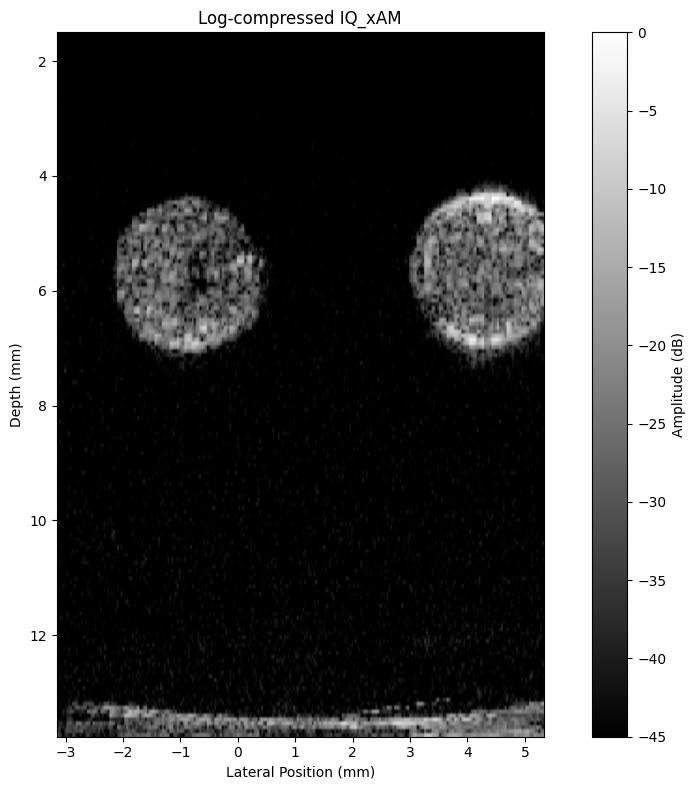

In [398]:
# Example usage:
img_log, envelope, lateral_mm, depth_mm = plot_beamformed_image(BFData, ReconParams, mode='AM')
# fig2, ax2 = plot_beamformed_image(BFData, ReconParams, mode='BMode')

In [439]:
-(lateral_mm[0]-lateral_mm[-1])


np.float64(8.47744)

In [440]:
(depth_mm[0]-depth_mm[-1])


np.float64(-12.26624)

In [277]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_envelope_with_square(envelope, lateral_mm, depth_mm,
                              x_mm=2.0, z_mm=10.5, width_mm=1.0,
                              cmap='gray', vmin=None, vmax=None,
                              figsize=(10, 8), show_colorbar=True,
                              title='Envelope with Square'):
    """
    Plot the envelope image and overlay a red square of given width
    centered at (x_mm, z_mm).

    Parameters
    ----------
    envelope : np.ndarray, shape (N_lateral, N_depth)
        The envelope data (linear magnitude) to be imaged.
    lateral_mm : np.ndarray, shape (N_lateral,)
        Lateral coordinates in mm (typically increasing left to right).
    depth_mm : np.ndarray, shape (N_depth,)
        Depth coordinates in mm (typically increasing with depth).
    x_mm : float, default=2.0
        Center lateral position of the square (mm).
    z_mm : float, default=10.5
        Center depth position of the square (mm).
    width_mm : float, default=1.0
        Side length of the square (mm).
    cmap : str, default='gray'
        Colormap for the envelope image.
    vmin, vmax : float, optional
        Color scale limits for the envelope image.
    figsize : tuple, default=(10, 8)
        Figure size in inches.
    show_colorbar : bool, default=True
        If True, add a colorbar.
    title : str, default='Envelope with Square'
        Plot title.

    Returns
    -------
    fig, ax : matplotlib.figure.Figure, matplotlib.axes.Axes
    """
    fig, ax = plt.subplots(figsize=figsize)

    extent = [lateral_mm[0], lateral_mm[-1], depth_mm[0], depth_mm[-1]]
    im = ax.imshow(envelope, extent=extent, aspect='equal',
                   cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel('Lateral Position (mm)')
    ax.set_ylabel('Depth (mm)')
    ax.set_title(title)

    # Draw the square (axis-aligned)
    half_w = width_mm / 2.0
    rect = Rectangle((x_mm - half_w, z_mm - half_w),
                     width_mm, width_mm,
                     linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    if show_colorbar:
        plt.colorbar(im, ax=ax)

    plt.tight_layout()

    # Compute mean inside the square, NOT WORKING TO FIX
    half_w = width_mm / 2.0
    lat_inside = (lateral_mm >= x_mm - half_w) & (lateral_mm <= x_mm + half_w)
    depth_inside = (depth_mm >= z_mm - half_w) & (depth_mm <= z_mm + half_w)

    print("lat_inside shape, depth_inside shape")
    print(lat_inside.shape, depth_inside.shape)
    
    mask_2d = lat_inside[:, np.newaxis] & depth_inside[np.newaxis, :]
    
    print("mask shape, envelope shape")
    print(mask_2d.shape, envelope.shape)

    inside_mean = envelope[mask_2d].mean()
    
    print(f"Mean intensity in square: {inside_mean:.4f}")

    print(mask_2d.shape)
    
    # Overlay mask for visual verification
    ax.imshow(np.flip(mask_2d.T, axis=0), alpha=0.3, extent=extent, cmap='Reds', interpolation='none')

    return fig, ax

In [406]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_envelope_with_square(envelope, lateral_mm, depth_mm,
                              x_mm=2.0, z_mm=10.5, width_mm=1.0,
                              cmap='gray', vmin=None, vmax=None,
                              figsize=(10, 8), show_colorbar=True,
                              title='Envelope with Square'):
    """
    Plot the envelope image and overlay a red square of given width
    centered at (x_mm, z_mm).

    Parameters
    ----------
    envelope : np.ndarray, shape (N_lateral, N_depth)
        The envelope data (linear magnitude) to be imaged.
    lateral_mm : np.ndarray, shape (N_lateral,)
        Lateral coordinates in mm (typically increasing left to right).
    depth_mm : np.ndarray, shape (N_depth,)
        Depth coordinates in mm (typically increasing with depth).
    x_mm : float, default=2.0
        Center lateral position of the square (mm).
    z_mm : float, default=10.5
        Center depth position of the square (mm).
    width_mm : float, default=1.0
        Side length of the square (mm).
    cmap : str, default='gray'
        Colormap for the envelope image.
    vmin, vmax : float, optional
        Color scale limits for the envelope image.
    figsize : tuple, default=(10, 8)
        Figure size in inches.
    show_colorbar : bool, default=True
        If True, add a colorbar.
    title : str, default='Envelope with Square'
        Plot title.

    Returns
    -------
    fig, ax : matplotlib.figure.Figure, matplotlib.axes.Axes
    """
    fig, ax = plt.subplots(figsize=figsize)

    extent = [lateral_mm[0], lateral_mm[-1], depth_mm[0], depth_mm[-1]]
    im = ax.imshow(envelope, extent=extent, aspect='equal',
                   cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel('Lateral Position (mm)')
    ax.set_ylabel('Depth (mm)')
    ax.set_title(title)

    # Draw the square (axis-aligned)
    half_w = width_mm / 2.0
    rect = Rectangle((x_mm - half_w, z_mm - half_w),
                     width_mm, width_mm,
                     linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    if show_colorbar:
        plt.colorbar(im, ax=ax)

    plt.tight_layout()

    # Compute mean inside the square, NOT WORKING TO FIX
    half_w = width_mm / 2.0
    lat_inside = (lateral_mm >= x_mm - half_w) & (lateral_mm <= x_mm + half_w)   # shape (N_lateral,)
    depth_inside = (depth_mm >= z_mm - half_w) & (depth_mm <= z_mm + half_w)     # shape (N_depth,)
    # Compute mask in original envelope coordinates
    mask_2d = lat_inside[:, np.newaxis] & depth_inside[np.newaxis, :]
    
    # Transform both envelope and mask to display orientation
    envelope_display = np.flip(envelope.T, axis=0)
    mask_display = np.flip(mask_2d.T, axis=0)
    
    # Compute mean in the display orientation (which matches the drawn square)
    inside_mean = envelope_display[mask_display].mean()
    
    print(inside_mean)
    
    # Overlay mask for visual verification
    # ax.imshow(np.flip(mask_2d.T, axis=0), alpha=0.3, extent=extent, cmap='Reds', interpolation='none')
    # ax.imshow(mask_2d, alpha=0.3, extent=extent, cmap='Reds', interpolation='none')
    ax.imshow(mask_display, alpha=0.1, extent=extent, cmap='Reds', interpolation='none')
    
    return fig, ax

In [436]:
def plot_envelope_with_square(envelope, lateral_mm, depth_mm,
                              x_mm=2.0, z_mm=10.5, width_mm=1.0,
                              cmap='gray', vmin=None, vmax=None,
                              figsize=(10, 8), show_colorbar=True,
                              title='Envelope with Square'):
    """
    Plot envelope with a red square and print mean intensity inside the square.

    The envelope is expected to have shape (N_depth, N_lateral), i.e.
    the first axis corresponds to depth and the second to lateral position.
    """
    # --- envelope is already (depth, lateral); no transpose needed ---
    fig, ax = plt.subplots(figsize=figsize)

    # Set extent: x = lateral, y = depth (reversed so shallow is top)
    extent = [lateral_mm[0], lateral_mm[-1],
              depth_mm[0], depth_mm[-1]]

    im = ax.imshow(envelope, extent=extent, aspect='equal',
                   cmap=cmap, vmin=vmin, vmax=vmax, origin='upper')

    ax.set_xlabel('Lateral Position (mm)')
    ax.set_ylabel('Depth (mm)')
    ax.set_title(title)

    # Draw the red square
    half_w = width_mm / 2.0
    rect = Rectangle((x_mm - half_w, z_mm - half_w),
                     width_mm, width_mm,
                     linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

    # Mask for pixels inside the square (depth, lateral)
    lat_inside = (lateral_mm >= x_mm - half_w) & (lateral_mm <= x_mm + half_w)
    depth_inside = (depth_mm >= z_mm - half_w) & (depth_mm <= z_mm + half_w)
    mask = depth_inside[:, np.newaxis] & lat_inside[np.newaxis, :]

    mask = np.flip(mask.T, axis=(0,1))
    
    # Mean intensity within the square
    inside_mean = envelope[mask].mean()
    print(f"Mean intensity in square: {inside_mean:.4f}")

    ax.imshow(mask, alpha=0.3, extent=extent, cmap='Reds', interpolation='none')
    
    if show_colorbar:
        plt.colorbar(im, ax=ax)
    plt.tight_layout()
    return fig, ax

Mean intensity in square: 110.8707


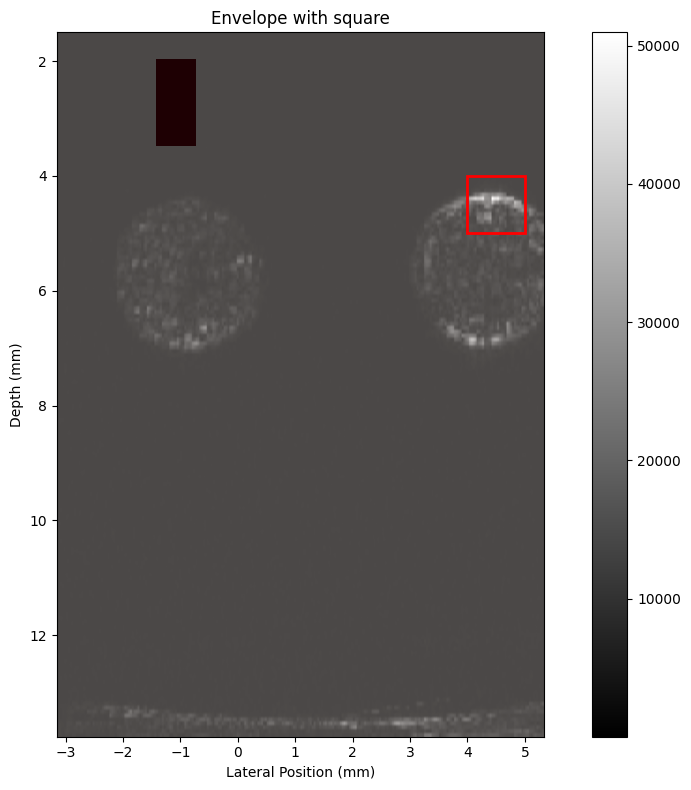

In [437]:
x_mm = 3.0
z_mm = 13.5

x_mm = 4.5
z_mm = 4.5

width_mm = 1

# Now plot the envelope with a square
fig2, ax2 = plot_envelope_with_square(
    envelope, lateral_mm, depth_mm,
    x_mm=x_mm, z_mm=z_mm, width_mm=width_mm,
    cmap='gray', title='Envelope with square'
)
plt.show()

In [408]:
## WORKING BUT SIDEWAYS

def plot_envelope_with_square(envelope, lateral_mm, depth_mm,
                              x_mm=2.0, z_mm=10.5, width_mm=1.0,
                              cmap='gray', vmin=None, vmax=None,
                              figsize=(10, 8), show_colorbar=True,
                              title='Envelope with Square'):
    # --- Transpose envelope to have shape (depth, lateral) ---
    envelope_disp = envelope.T                     # shape (N_depth, N_lateral)
    
    # Create the figure and axes (same as before)
    fig, ax = plt.subplots(figsize=figsize)
    
    # Set extent: x = lateral, y = depth
    # If depth increases downward (common in ultrasound), flip y coordinates
    # so that shallow depth appears at the top.
    # Here we assume depth_mm is increasing with depth.
    extent = [lateral_mm[0], lateral_mm[-1],
              depth_mm[-1], depth_mm[0]]   # y reversed: top = shallow
    
    # Display the transposed envelope
    im = ax.imshow(envelope_disp, extent=extent, aspect='equal',
                   cmap=cmap, vmin=vmin, vmax=vmax, origin='upper')
    
    ax.set_xlabel('Lateral Position (mm)')
    ax.set_ylabel('Depth (mm)')
    ax.set_title(title)
    
    # Draw the red square (same physical coordinates)
    half_w = width_mm / 2.0
    rect = Rectangle((x_mm - half_w, z_mm - half_w),
                     width_mm, width_mm,
                     linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    
    # --- Compute the mask for the square (now in (depth, lateral) shape) ---
    lat_inside = (lateral_mm >= x_mm - half_w) & (lateral_mm <= x_mm + half_w)
    depth_inside = (depth_mm >= z_mm - half_w) & (depth_mm <= z_mm + half_w)
    
    # Note: first dimension is depth, second is lateral
    mask_disp = depth_inside[:, np.newaxis] & lat_inside[np.newaxis, :]
    
    # Compute the mean on the transposed envelope using the matching mask
    inside_mean = envelope_disp[mask_disp].mean()
    print(f"Mean intensity in square: {inside_mean:.4f}")
    
    if show_colorbar:
        plt.colorbar(im, ax=ax)
    plt.tight_layout()
    return fig, ax


Mean intensity in square: 2916.1150


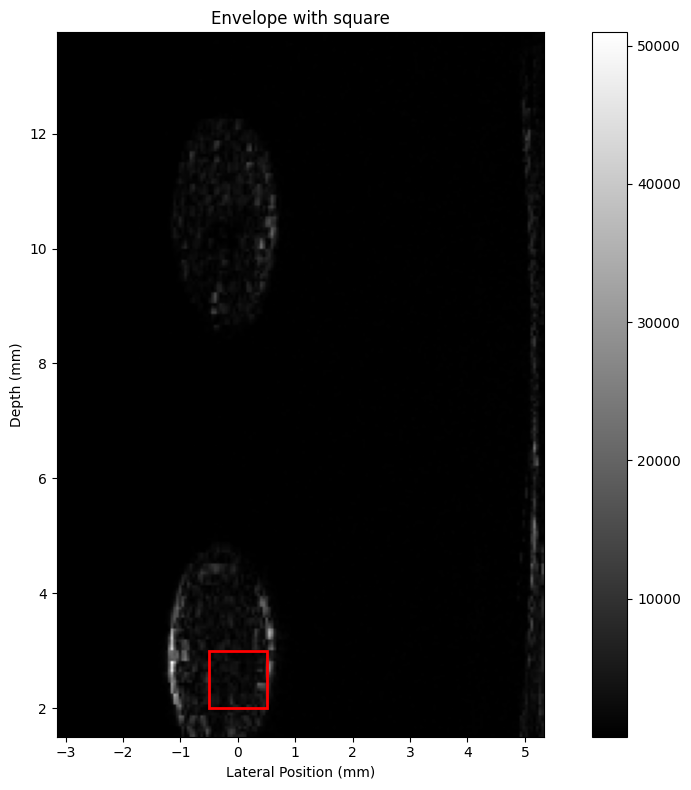

In [410]:
x_mm = 3.0
z_mm = 13.5

x_mm = -0.0
z_mm = 2.5

width_mm = 1

# Now plot the envelope with a square
fig2, ax2 = plot_envelope_with_square(
    envelope, lateral_mm, depth_mm,
    x_mm=x_mm, z_mm=z_mm, width_mm=width_mm,
    cmap='gray', title='Envelope with square'
)
plt.show()